# 201 — Re-evaluate baseline Pareto designs under known T scenarios

This notebook holds the baseline `fish_dollars` Pareto designs fixed and re-evaluates them under baseline T, T −10%, and T +10%.

This answers: **What is the hydrologic cost of using designs optimized under the wrong transmissivity value?**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import uncertainty_project_helpers as up
up.apply_plot_style()

# -----------------------------
# User-editable settings
# -----------------------------
RUN_NAME = "fish_dollars_baseline_0.0_1.0_0.01"
N_TEST_MEMBERS = None
RERUN_REEVALUATION = False

HISTORIC_STREAMFLOW_CFS = 8.6
DEPLETION_OBS_NAME = "lpr:total_combined:bdpl"
PUMPING_COLUMN_FOR_HYDRO_PLOTS = "effective_total_pumping_cfs"

# T scenarios: label -> T multiplier relative to the baseline PyCap T.
T_SCENARIOS = {
    "T_minus_10pct": 0.90,
    "baseline_T": 1.00,
    "T_plus_10pct": 1.10,
}

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = up.find_lpr_pycap_opt_dir(NOTEBOOK_DIR)
dirs = up.make_project_dirs(NOTEBOOK_DIR, "201", "reevaluate_baseline_pareto_under_T_scenarios")
OUTPUT_DIR = dirs["output_dir"]
CACHE_DIR = dirs["cache_dir"]
CACHE_FILE = CACHE_DIR / "201_T_scenario_reevaluation_long.csv"
ERROR_CACHE_FILE = CACHE_DIR / "201_T_scenario_reevaluation_errors.csv"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)

PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/cached_reevaluations/201_T_scenario_reevaluation_long.csv


In [2]:
# -----------------------------
# Load source-of-truth model context and design set
# -----------------------------
context = up.load_fish_dollars_context(RUN_NAME, PROJECT_DIR)
pareto_archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(pareto_archive, n_test_members=N_TEST_MEMBERS)
dv_df = up.load_decision_variable_population(context.run_dir)
q_cols = up.get_q_columns(dv_df)
missing_members = sorted(set(pareto_final["member"]) - set(dv_df.index.astype(str)))

print("Using script:", context.script_path)
print("Final feasible front-1 members:", len(pareto_final))
print("Baseline T:", context.base_T)
print("Missing final members in dv_df:", len(missing_members))
if missing_members:
    raise KeyError(f"Missing Pareto members in dv_pop files. First few: {missing_members[:10]}")

pd.DataFrame({
    "scenario": list(T_SCENARIOS.keys()),
    "T_factor": list(T_SCENARIOS.values()),
    "T_value": [context.base_T * f for f in T_SCENARIOS.values()],
})

Using script: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01/run_pycap_standalone_opt_mou_fish_dollars.py
Final feasible front-1 members: 174
Baseline T: 1700.0
Missing final members in dv_df: 0


,scenario,T_factor,T_value
0,T_minus_10pct,0.9,1530.0
1,baseline_T,1.0,1700.0
2,T_plus_10pct,1.1,1870.0


In [ ]:
# -----------------------------
# Re-evaluate under T scenarios, or load cached results
# -----------------------------
if CACHE_FILE.exists() and not RERUN_REEVALUATION:
    print("Loading cached T-scenario re-evaluation:", CACHE_FILE)
    results_long = pd.read_csv(CACHE_FILE)
    error_df = pd.read_csv(ERROR_CACHE_FILE) if ERROR_CACHE_FILE.exists() else pd.DataFrame()
else:
    results_long, error_df = up.reevaluate_designs(
        pareto_final=True,
        dv_df=dv_df,
        q_cols=q_cols,
        context=context,
        scenarios=T_SCENARIOS,
        historic_streamflow_cfs=HISTORIC_STREAMFLOW_CFS,
        depletion_obs_name=DEPLETION_OBS_NAME,
    )t
    results_long.to_csv(CACHE_FILE, index=False)
    if not error_df.empty:
        error_df.to_csv(ERROR_CACHE_FILE, index=False)
    print("Saved cache:", CACHE_FILE)

results_long = up.add_known_T_error_metrics(results_long, baseline_label="baseline_T")
results_wide = up.make_wide_by_scenario(results_long)
scenario_summary = up.summarize_known_T_scenarios(results_long)

display(scenario_summary)


Scenario: T_minus_10pct | T factor: 0.9 | T value: 1530
  Re-evaluating 1 of 522: scenario=T_minus_10pct, member=gen=47_member=5907_pso
  Re-evaluating 50 of 522: scenario=T_minus_10pct, member=gen=41_member=5214_pso
  Re-evaluating 100 of 522: scenario=T_minus_10pct, member=gen=47_member=5999_pso
  Re-evaluating 150 of 522: scenario=T_minus_10pct, member=gen=34_member=4241_pso

Scenario: baseline_T | T factor: 1 | T value: 1700
  Re-evaluating 200 of 522: scenario=baseline_T, member=gen=38_member=4778_pso
  Re-evaluating 250 of 522: scenario=baseline_T, member=gen=24_member=2976_pso
  Re-evaluating 300 of 522: scenario=baseline_T, member=gen=33_member=4206_pso

Scenario: T_plus_10pct | T factor: 1.1 | T value: 1870
  Re-evaluating 350 of 522: scenario=T_plus_10pct, member=56
  Re-evaluating 400 of 522: scenario=T_plus_10pct, member=gen=45_member=5714_pso
  Re-evaluating 450 of 522: scenario=T_plus_10pct, member=gen=46_member=5794_pso
  Re-evaluating 500 of 522: scenario=T_plus_10pct,

,scenario,T_factor,T_value,n_members,mean_effective_total_pumping_cfs,mean_depletion_cfs,mean_streamflow_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,T_minus_10pct,0.9,1530.0,174,107.288405,2.544795,6.055205,0.160708,0.160708,0.254155,0.000000,0.000000
1,baseline_T,1.0,1700.0,174,107.288405,2.705503,5.894497,0.000000,0.000000,0.000000,0.000000,0.000000
2,T_plus_10pct,1.1,1870.0,174,107.288405,2.856156,5.743844,-0.150653,0.150653,0.235821,0.150653,0.235821


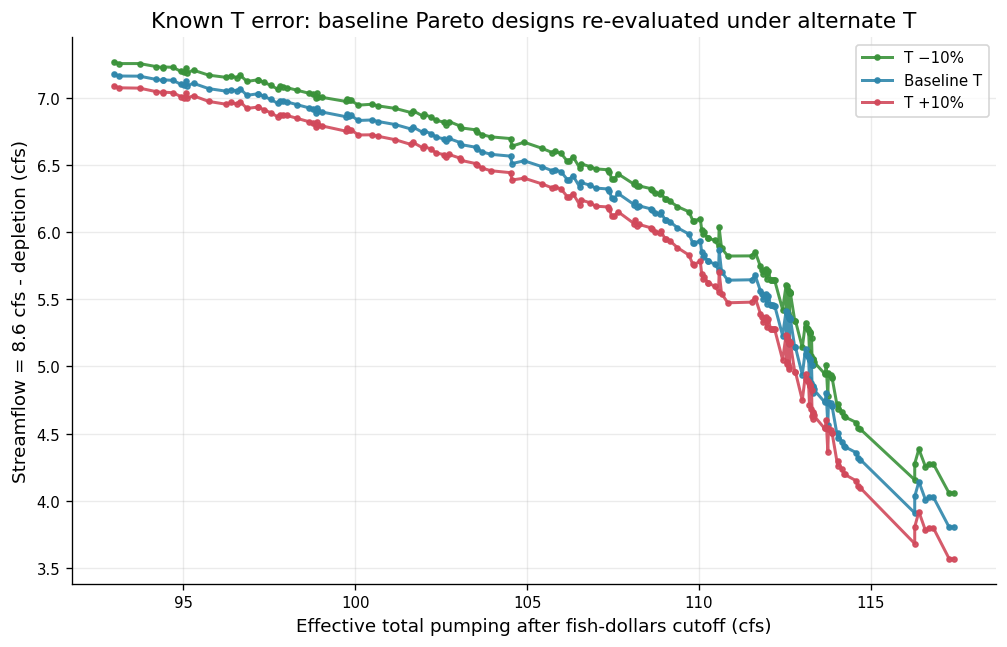

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_pumping_vs_streamflow_T_scenarios.png


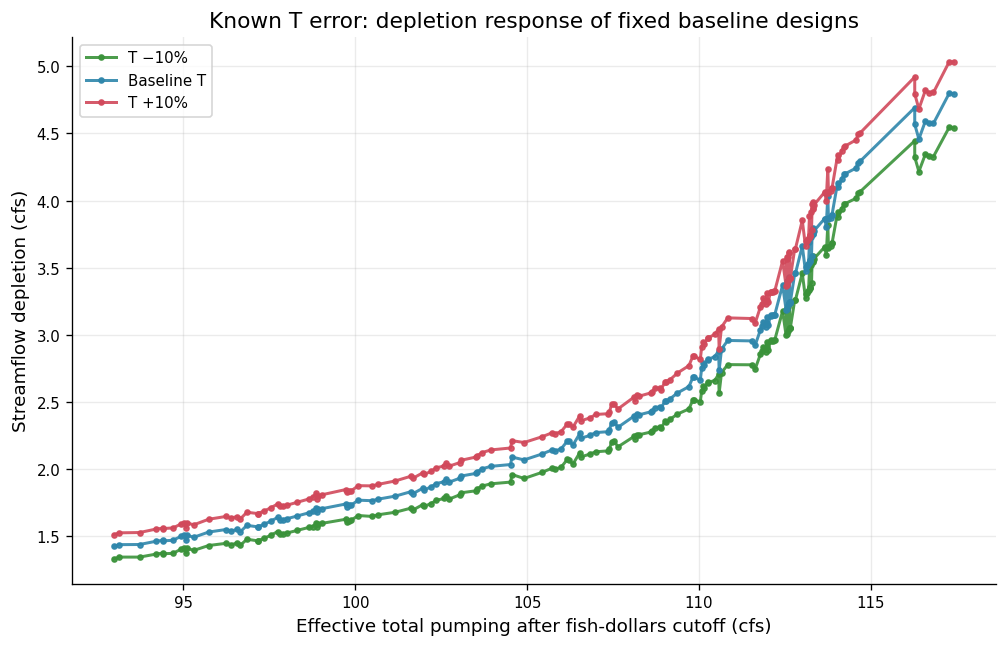

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_pumping_vs_depletion_T_scenarios.png


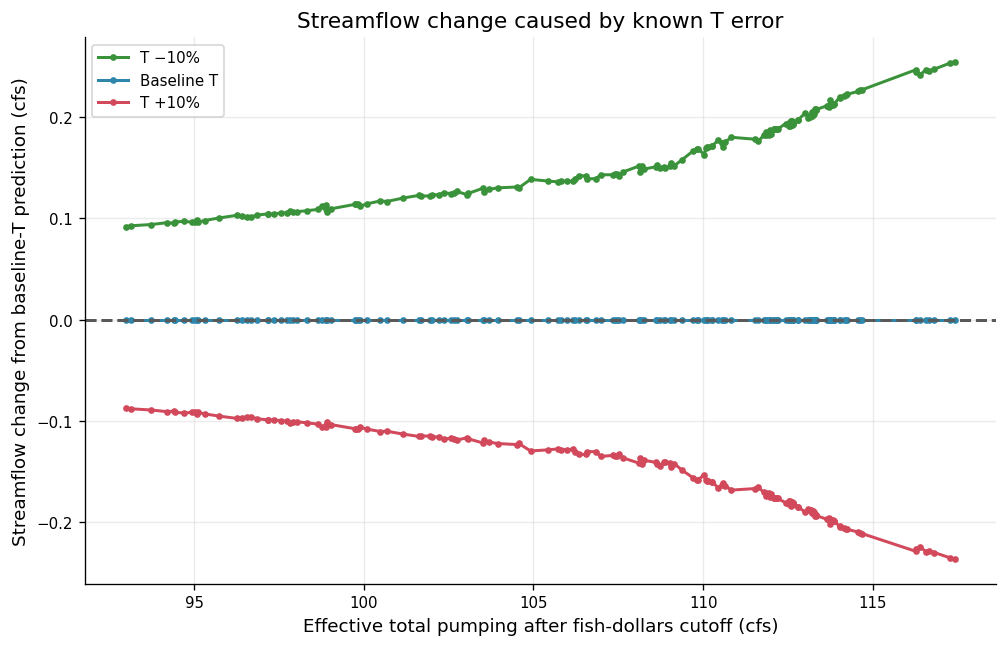

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_streamflow_change_from_baseline_vs_pumping.png


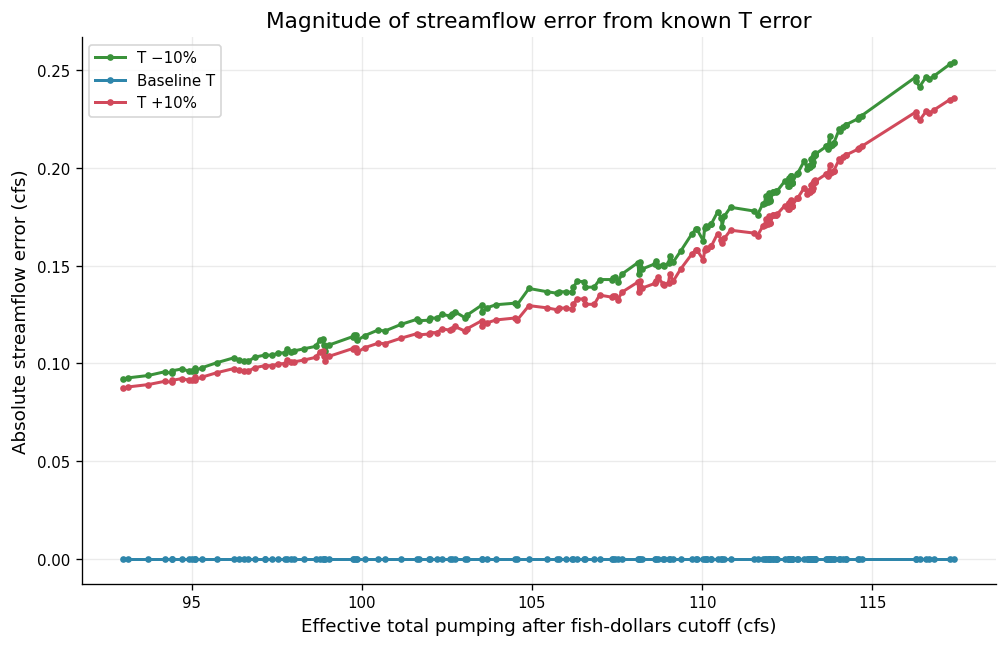

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_absolute_streamflow_error_vs_pumping.png


In [4]:
# -----------------------------
# Plots
# -----------------------------
up.plot_scenario_lines(
    results_wide,
    xcol=PUMPING_COLUMN_FOR_HYDRO_PLOTS,
    ycols_by_scenario={
        "T_minus_10pct": "streamflow_cfs__T_minus_10pct",
        "baseline_T": "streamflow_cfs__baseline_T",
        "T_plus_10pct": "streamflow_cfs__T_plus_10pct",
    },
    xlabel="Effective total pumping after fish-dollars cutoff (cfs)",
    ylabel="Streamflow = 8.6 cfs - depletion (cfs)",
    title="Known T error: baseline Pareto designs re-evaluated under alternate T",
    outfile=OUTPUT_DIR / "201_pumping_vs_streamflow_T_scenarios.png",
)

up.plot_scenario_lines(
    results_wide,
    xcol=PUMPING_COLUMN_FOR_HYDRO_PLOTS,
    ycols_by_scenario={
        "T_minus_10pct": "depletion_cfs__T_minus_10pct",
        "baseline_T": "depletion_cfs__baseline_T",
        "T_plus_10pct": "depletion_cfs__T_plus_10pct",
    },
    xlabel="Effective total pumping after fish-dollars cutoff (cfs)",
    ylabel="Streamflow depletion (cfs)",
    title="Known T error: depletion response of fixed baseline designs",
    outfile=OUTPUT_DIR / "201_pumping_vs_depletion_T_scenarios.png",
)

plot_df = up.sort_for_plot(results_long, PUMPING_COLUMN_FOR_HYDRO_PLOTS)
fig, ax = plt.subplots()
for scen, group in plot_df.groupby("scenario", sort=False):
    ax.plot(group[PUMPING_COLUMN_FOR_HYDRO_PLOTS], group["streamflow_change_from_baseline_cfs"], marker="o", markersize=3, label=up.SCENARIO_LABELS.get(scen, scen), color=up.SCENARIO_COLORS.get(scen))
ax.axhline(0, linestyle="--", color="0.35")
ax.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax.set_ylabel("Streamflow change from baseline-T prediction (cfs)")
ax.set_title("Streamflow change caused by known T error")
ax.legend()
up.save_figure(fig, OUTPUT_DIR / "201_streamflow_change_from_baseline_vs_pumping.png")

fig, ax = plt.subplots()
for scen, group in plot_df.groupby("scenario", sort=False):
    ax.plot(group[PUMPING_COLUMN_FOR_HYDRO_PLOTS], group["absolute_streamflow_error_cfs"], marker="o", markersize=3, label=up.SCENARIO_LABELS.get(scen, scen), color=up.SCENARIO_COLORS.get(scen))
ax.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax.set_ylabel("Absolute streamflow error (cfs)")
ax.set_title("Magnitude of streamflow error from known T error")
ax.legend()
up.save_figure(fig, OUTPUT_DIR / "201_absolute_streamflow_error_vs_pumping.png")

In [5]:
# -----------------------------
# Save outputs
# -----------------------------
results_long.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_long.csv", index=False)
results_wide.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_wide.csv", index=False)
scenario_summary.to_csv(OUTPUT_DIR / "201_T_scenario_summary.csv", index=False)
if not error_df.empty:
    error_df.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_errors.csv", index=False)

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f.name)

Saved files:
 - 201_T_scenario_reevaluation_long.csv
 - 201_T_scenario_reevaluation_wide.csv
 - 201_T_scenario_summary.csv
 - 201_absolute_streamflow_error_vs_pumping.png
 - 201_pumping_vs_depletion_T_scenarios.png
 - 201_pumping_vs_streamflow_T_scenarios.png
 - 201_streamflow_change_from_baseline_vs_pumping.png
